# Nodal Markets on the WSCC 9-Bus Network — Fundamentals

This is the first notebook in the illustrative series. It builds the WSCC / IEEE
9-bus test case, clears a single nodal energy market on it, and reads off the
pieces every later notebook reuses: **locational marginal prices (LMPs)**,
**congestion rent**, **transport (net-interchange) constraints and transfer
rent**, and **self-schedules**. It closes with the three settlement **ledgers**
and a **sandbox** for dialling scenarios and watching the revenue flows respond.

It poses no market *issue* of its own — the seam and congestion-revenue-allocation
issues live in the 200- and 300-series notebooks. Everything here runs on the
shared teaching libraries (`wscc9_model`, `footprints`, `revenue_allocation`,
`wscc9_figures`) built on the `seams_engine` PTDF DC-OPF and the `nodal_plot`
figures.

## 0. Setup

In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
              "wscc9_model.py", "footprints.py", "revenue_allocation.py", "wscc9_figures.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

# Teaching libraries for the WSCC 9-bus illustrative repository.
import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

# Clean tables on PDF export: give DataFrames/Series a booktabs LaTeX rendering.
# Jupyter and Colab still show the normal HTML tables; `nbconvert --to pdf` picks
# up this text/latex representation, so tables come out as real ruled tables.
def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready


### Generation & load table

The 9-bus system has three generators and three
loads. 

```
        (1)gen $50            (3)gen $20
          |                     |
         [4]---[5]load--------[6]---[7]load
          |                     |
         [9]load---[8]---------/
                    |
                  (2)gen $35
```
Lines (rating MW): `0:1-4(250) 1:4-5(250) 2:5-6(150) 3:3-6(300) 4:6-7(150) 5:7-8(250) 6:8-2(250) 7:8-9(250) 8:9-4(250)`

In [3]:
# The teaching fleet and loads live in wscc9_model (edit there to change the
# baseline, or override the dicts here). Bus 3 is the CHEAPEST unit ($20), bus 1
# the most expensive ($50) — a price gradient that makes congestion bite.
GEN_FLEET = dict(wm.DEFAULT_GEN_FLEET)   # {gen: {bus, cost $/MWh, p_nom MW}}
LOADS     = dict(wm.DEFAULT_LOADS)       # {bus: MW}

print('loads (MW):', LOADS)
pd.DataFrame(GEN_FLEET).T[['bus', 'cost', 'p_nom']]

loads (MW): {'5': 90.0, '7': 100.0, '9': 125.0}


,bus,cost,p_nom
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0


## 1. Shared network & shift factors

> *A net injection of $p$ MW at bus $n$ produces an incremental flow of
> $SF_{n,m}\,p$ on constraint $m$.*

Each engine's flow $F^M_m=\sum_n SF_{n,m}\,p^{\text{inj},M}_n$
and the LMP congestion term $\sum_m SF_{n,m}\mu_m$ is built.

In [4]:
pt = shift_factors()   # DC shift-factor matrix (PTDF) of the base network
print('Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)')
sf_table(pt)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)


,bus 1,bus 2,bus 3,bus 4,bus 5,bus 6,bus 7,bus 8,bus 9
line_0 (1-4),0.0,-1.000,-1.000,-1.0,-1.000,-1.000,-1.000,-1.000,-1.000
line_1 (4-5),0.0,-0.361,-0.615,-0.0,-0.865,-0.615,-0.467,-0.361,-0.125
line_2 (5-6),0.0,-0.361,-0.615,-0.0,0.135,-0.615,-0.467,-0.361,-0.125
line_3 (3-6),0.0,0.000,1.000,-0.0,0.000,0.000,-0.000,0.000,0.000
line_4 (6-7),0.0,-0.361,0.385,0.0,0.135,0.385,-0.467,-0.361,-0.125
line_5 (7-8),0.0,-0.361,0.385,-0.0,0.135,0.385,0.533,-0.361,-0.125
line_6 (8-2),0.0,-1.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000
line_7 (8-9),0.0,0.639,0.385,0.0,0.135,0.385,0.533,0.639,-0.125
line_8 (9-4),0.0,0.639,0.385,0.0,0.135,0.385,0.533,0.639,0.875


### Line admittance map

The WSCC 9-bus assigns a distinct reactance $x_m$ to every line. For DC flow the
power a line carries per unit of angle difference across its **susceptance**
$b_m = 1/x_m$. The cell below draws each line with a width
proportional to $b_m$ (wider = lower $x$ = more admittance), giving a physical
picture of where power prefers to flow before any dispatch is chosen. 

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines
INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


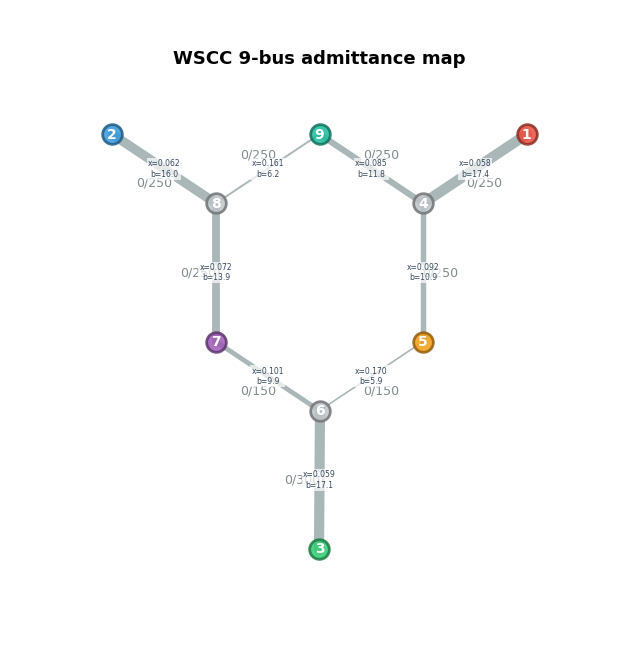

,x (reactance),b = 1/x,draw width
line_0 (1-4),0.0576,17.36,7.50
line_3 (3-6),0.0586,17.06,7.34
line_6 (8-2),0.0625,16.00,6.75
line_5 (7-8),0.0720,13.89,5.59
line_8 (9-4),0.0850,11.76,4.43
line_1 (4-5),0.0920,10.87,3.94
line_4 (6-7),0.1008,9.92,3.42
line_7 (8-9),0.1610,6.21,1.38
line_2 (5-6),0.1700,5.88,1.20


In [5]:
pt = compute_ptdf(build_network(), slack_bus='1')
widths = susceptance_widths(pt, wmin=1.2, wmax=7.5)   # {line: linewidth} from b = 1/x

# Colour the nodes with the SAME per-bus palette used throughout the notebook:
# gen/load buses take their palette colour, pure transit buses stay grey. The
# membership comes from the fleet (not the dispatch), so these node colours match
# the dispatched figures exactly -- this is purely a susceptance map, no flows.
node_colors = BUS_COLORS   # canonical per-bus palette (defined with pt above)

# Pure susceptance map: no dispatch annotations, no flows -- width encodes
# admittance only, nodes carry the standard palette colour.
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=node_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines},   # 0 flow -> no arrows, grey lines
    line_widths=widths,
    title='WSCC 9-bus admittance map', #  (wider = lower reactance = carries more flow per unit angle)
)
# annotate each line with its x and b
for l, (b0, b1) in zip(pt.lines, pt.line_buses):
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    b = pt.susceptance[pt.line_idx[l]]
    ax.text(xm, ym, f'x={1/b:.3f}\nb={b:.1f}', fontsize=5.5, ha='center', va='center',
            color='#34495E', bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.8), zorder=6)
plt.show()

pd.DataFrame({
    'x (reactance)': [round(1 / pt.susceptance[pt.line_idx[l]], 4) for l in pt.lines],
    'b = 1/x': [round(pt.susceptance[pt.line_idx[l]], 2) for l in pt.lines],
    'draw width': [round(widths[l], 2) for l in pt.lines],
}, index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)]).sort_values('b = 1/x', ascending=False)

## 2. Market engine and nodal dispatch

### The dispatch each engine solves, its Lagrangian, and the bus prices

`solve_engine_dispatch` clears **one engine's** DC-OPF on the shared network: a
bid-based security-constrained economic dispatch (SCED) reduced to a **single
period with energy-cost bids only** (no unit commitment) and a **single
system-wide energy balance**. An engine $M$ brings its resources $\mathcal R^M$
(cost $c_i$, cap $\bar g_i$ at bus $\mathrm{bus}(i)$), its served load $d^M_n$, an
activated line set $\mathcal M^M_{\mathrm{act}}$, and any **exogenous** cross-footprint
schedule $\mathrm{exo}^M_n$ (zero for a stand-alone clear).

**Nomenclature.** Sets are script capitals; an element is the matching
lower-case letter (upper-case for markets).

| Symbol | Definition |
|---|---|
| $\mathcal N$ | the set of buses in the network; $n\in\mathcal N$ |
| $\mathcal M$ | the set of monitored lines (network constraints); $m\in\mathcal M$ |
| $\mathcal E$ | the set of market engines operating on the shared network; $M\in\mathcal E$ |
| $\mathcal R^M$ | the set of resources (generators) cleared by market $M$; $i\in\mathcal R^M$ |
| $\mathcal M^M_{\mathrm{act}}\subseteq\mathcal M$ | the lines whose limits market $M$ activates (enforces) in its clearing |
| $c_i,\ \bar g_i,\ \mathrm{bus}(i)$ | marginal cost, capacity, and host bus of resource $i$ |
| $g_i$ | dispatch of resource $i$ — the engine's decision variable, $0\le g_i\le\bar g_i$ |
| $d^M_n$ | load served by market $M$ at bus $n$ (zero wherever $M$ serves no load) |
| $SF_{n,m}$ | shift factor of bus $n$ on line $m$ |
| $\bar F_m$ | operating limit of line $m$ |
| $\mathrm{exo}^M_n$ | exogenous scheduled injection at bus $n$ in market $M$'s clear (fixed before it runs) |
| $u_n$ | unserved (shed) load at bus $n$ — the relaxation variable, $0\le u_n\le d^M_n$ (zero unless the relaxation is enabled) |
| $V$ | load-shed penalty price, \$/MWh (`SHED_PRICE`; the engine's `shed_price`) |

Case carries meaning here: lower-case $m$ indexes a **line**, upper-case $M$
names a **market engine** drawn from $\mathcal E$, and script $\mathcal M$ is
the set of lines — three different objects. The formulation is written for a
general $M\in\mathcal E$; the unified clearing of this section is the special
case where $\mathcal E$ has a single member spanning every bus.


**Objective — minimise the engine's own dispatch cost.**

$$\min_{0\le g_i\le \bar g_i}\ \ C^M=\sum_{i\in\mathcal R^M} c_i\,g_i. \qquad\qquad(1)$$

*In words.* Stack up the engine's own generators cheapest-first to cover its obligation
(no-load, start-up and shut-down terms drop out in this single-period, energy-only cut).

**Energy balance — its dual is the energy price $\lambda^M$.**

$$\sum_{i\in\mathcal R^M} g_i=\sum_{n\in\mathcal N} d^M_n-\sum_{n\in\mathcal N} \mathrm{exo}^M_n,\   \ [\lambda^M]\qquad\qquad(2)\quad$$

*In words.* The engine's generation serves its own load net of any scheduled interchange:
$\mathrm{exo}^M_n>0$ is power injected into the footprint (an import), $\mathrm{exo}^M_n<0$ a
withdrawal (an export). $\lambda^M$ is the single system-wide energy price (`res.energy_price`). Note the
**market scoping sits on the data, not the bus set**: the sums run over every bus
$n\in\mathcal N$, but $d^M_n$ vanishes wherever $M$ serves no load, and $\mathrm{exo}^M_n$
may sit at *any* bus of the shared network.

**Feasibility relaxation — load shedding at a penalty.** Constraint (2) can be
impossible to satisfy — load behind a binding line with too little reachable
generation — and a market clearing must not simply fail. The engine therefore
carries an **opt-in power-balance relaxation** (`shed_price`; the `# -- EDIT --`
cell below sets `SHED_PRICE = 150` \$/MWh): every load bus gains an
unserved-load variable $u_n$, penalised in the objective and netted from the
load it relaxes,

$$\min\ \sum_{i\in\mathcal R^M} c_i\,g_i+V\!\sum_{n\in\mathcal N} u_n,\qquad
  \sum_{i\in\mathcal R^M} g_i=\sum_{n\in\mathcal N}\big(d^M_n-u_n\big)-\sum_{n\in\mathcal N}\mathrm{exo}^M_n,\qquad
  0\le u_n\le d^M_n,$$

with every flow built from the **served** load $d^M_n-u_n$. Mechanically $u_n$
is a virtual generator at the load bus with cost $V$: nothing sheds while
cheaper supply can still reach the bus, and wherever shedding is interior the
bus price is exactly $\lambda^M_n=V$ — the relaxation penalty doubles as the
price cap. (EDAM relaxes each BAA's power balance the same way: energy
supply-shortfall variables priced at penalty costs in the objective.) The
equations below are written without $u_n$; in every worked example the
relaxation is enabled but slack ($u_n=0$ throughout).

**Flow and activated limits — duals $\mu^M_m$.**

$$F^M_m=\sum_{n\in\mathcal N} SF_{n,m}\,p^{\mathrm{inj},M}_n\ \ (m\in\mathcal M),\qquad
  -\bar F_m\le F^M_m\le \bar F_m\ \ [\mu^M_m]\ \ (m\in\mathcal M^M_{\mathrm{act}}),\qquad
  p^{\mathrm{inj},M}_n=\!\!\!\sum_{i\in\mathcal R^M:\,\mathrm{bus}(i)=n}\!\!\!g_i-d^M_n+\mathrm{exo}^M_n\ \ (n\in\mathcal N). \qquad(3)$$

*In words.* The engine's flow on a line is the shift-factor-weighted sum of **its own** net
injections, held within the rating **only on the lines it activates**. A line outside
$\mathcal M^M_{\mathrm{act}}$ has its limit relaxed and stays silent (`activated_lines`).

**The Lagrangian.**

$$\mathcal L^M(g,\lambda^M,\mu^M,\underline\mu^M,\overline\mu^M)=\sum_{i\in\mathcal R^M} c_i\,g_i-\lambda^M\!\Big(\sum_{i\in\mathcal R^M} g_i-\sum_{n\in\mathcal N} d^M_n+\sum_{n\in\mathcal N}\mathrm{exo}^M_n\Big)-\!\!\sum_{m\in\mathcal M^M_{\mathrm{act}}}\!\!\mu^M_m\,F^M_m+\sum_{i\in\mathcal R^M}\overline\mu^M_i\,(g_i-\bar g_i)-\sum_{i\in\mathcal R^M}\underline\mu^M_i\,g_i. \qquad(4)$$

*In words.* Cost, minus the energy-balance multiplier times the imbalance, minus each activated
line's (signed) congestion multiplier times the flow on it, plus one multiplier per generator
capacity limit: $\overline\mu^M_i\ge 0$ on the upper limit $g_i\le\bar g_i$ and
$\underline\mu^M_i\ge 0$ on the lower limit $g_i\ge 0$. $\lambda^M$ and the $\mu^M_m$ are exactly
`res.energy_price` and `res.line_dual`.

**Complementary slackness.** Each capacity multiplier is non-zero only when its own limit binds:

$$\overline\mu^M_i\,(g_i-\bar g_i)=0,\qquad \underline\mu^M_i\,g_i=0,\qquad \overline\mu^M_i,\underline\mu^M_i\ge 0,\qquad \forall\,i\in\mathcal R^M.$$

A fully-loaded unit ($g_i=\bar g_i$) may carry $\overline\mu^M_i>0$, an idle unit ($g_i=0$) may
carry $\underline\mu^M_i>0$, and a **marginal** unit ($0<g_i<\bar g_i$) has both equal to zero.

**Stationarity — where the price comes from.** At the optimum the Lagrangian is stationary in
each dispatch variable. For a generator $i$ at bus $n=\mathrm{bus}(i)$, using $\partial F^M_m/\partial g_i=SF_{n,m}$:

$$\frac{\partial \mathcal L^M}{\partial g_i}
  = c_i-\lambda^M-\!\!\sum_{m\in\mathcal M^M_{\mathrm{act}}}\!\!SF_{n,m}\,\mu^M_m\;+\;\overline\mu^M_i-\underline\mu^M_i\;=\;0 .$$

For a **marginal** unit the two bound multipliers vanish by complementary slackness, so the
$\overline\mu^M_i-\underline\mu^M_i$ term drops and we are left with
$c_i=\lambda^M+\sum_{m}SF_{n,m}\,\mu^M_m$.

**Nodal LMP — the price at every bus.**

$$\lambda^M_n=\lambda^M+\sum_{m\in\mathcal M^M_{\mathrm{act}}}SF_{n,m}\,\mu^M_m\ \ (n\in\mathcal N). \qquad\qquad(5)$$

*In words.* A bus's price is the system energy price plus, for every binding activated line, that
line's shadow price scaled by the bus's shift factor onto it. With nothing binding, every bus
collapses to the one price $\lambda^M$. **Section 2 runs the unified counterfactual**: a single
engine over **all** buses with $\mathrm{exo}=0$ and every limit enforced — the single-price
benchmark the rest of the notebook builds on.

### Congestion rent

Unified clearing is the single engine over **all** buses ($\mathrm{exo}=0$, every
line activated), so we drop the engine superscript: write $\lambda_n\equiv\lambda^M_n$,
$\mu_m\equiv\mu^M_m$, $d_n\equiv d^M_n$, and $\mathcal M_{\mathrm{act}}$ for the activated set; let
$g_n=\sum_{i:\,\mathrm{bus}(i)=n} g_i$ be the dispatch at bus $n$. Value each binding
line's limit at its shadow price — equivalently, net the bus-level payments:

$$R=\sum_{m\in\mathcal M_{\mathrm{act}}}|\mu_m|\,|F_m|
   =\underbrace{\sum_{n\in\mathcal N}\lambda_n d_n}_{\text{paid by load}}
   -\underbrace{\sum_{n\in\mathcal N}\lambda_n g_n}_{\text{paid to generation}}. \qquad (6)$$

*In words.* The congestion rent (merchandising surplus) is the shadow price of each binding
line times the power on it — and it equals exactly what load pays minus what generation is
paid, because the energy components net to zero (total generation $=$ total load). **No
binding line $\Rightarrow$ no price separation $\Rightarrow R=0$.** 

**Edit below:** generator costs, load levels, and line ratings. Limiting a line rating may
create congestion and price separation on the constrained
path.

In [6]:
# -- EDIT -- unified-clearing inputs --------------------------------------
COST_OVERRIDE   = {}                      # e.g. {'gen_0': 45.0} to re-bid the $35 unit
LOAD_OVERRIDE   = {}                      # e.g. {'7': 130.0}
LINE_RATINGS    = {'line_4': 40.0, 'line_1': 30.0, 'line_2': 30.0}   # adjust line_4 (6-7, internal to BA-1) below its ~63 MW natural flow
SHED_PRICE      = 150.0   # $/MWh -- load-shed (power-balance relaxation) penalty; None disables
# -------------------------------------------------------------------------

net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

unified = make_engine('UNIFIED', buses=pt.buses)
for g, c in COST_OVERRIDE.items(): unified.gens[g]['cost'] = c
for b, v in LOAD_OVERRIDE.items(): unified.loads[b] = v

res = solve_engine_dispatch(pt, unified, shed_price=SHED_PRICE)
print('dispatch (MW):', {k: round(v, 1) for k, v in res.dispatch.items()})
print('energy price :', round(res.energy_price, 2), '$/MWh')
binding = {k: round(v, 1) for k, v in res.line_dual.items() if abs(v) > 1e-3}
print('binding lines:', binding or 'none')
print('load shed    :', {b: round(v, 1) for b, v in res.shed_by_bus.items()} or 'none')
print()
print('LMP by bus ($/MWh):')
pd.Series({b: round(res.lmp[b], 2) for b in pt.buses}).to_frame('LMP').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


dispatch (MW):

{'gen_slack_0': 101.1, 'gen_0': 113.9, 'gen_1': 70.0}

energy price :

50.0

...

{'line_1': -94.4, 'line_2': 140.4, 'line_4': -4.5}

load shed    :

{'5': 30.0}

LMP by bus ($/MWh):

,1,2,3,4,5,6,7,8,9
LMP,50.0,35.0,20.0,50.0,150.0,20.0,30.61,35.0,44.82


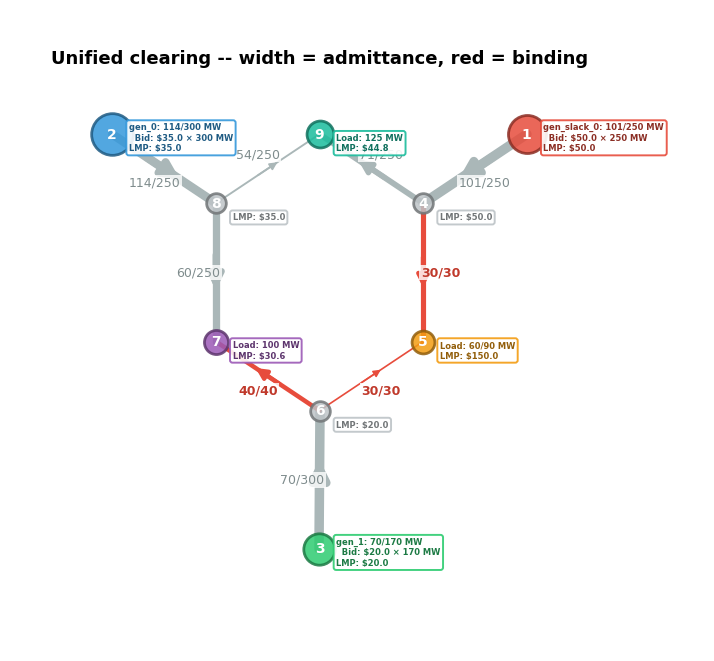

In [7]:
# Topology with DC power flow. Line WIDTH = susceptance (b=1/x); line COLOUR =
# congestion. A line is red only when its shadow price is non-zero (a genuine
# binding transmission limit) -- NOT merely when flow hits rating, which can
# happen because the generator behind a radial line is maxed out.
sup, dem = to_supply_demand(unified, res)
colors = dict(BUS_COLORS)   # canonical colours; a subset clearing no longer reshuffles them
flows = {l: res.flow_own[l] for l in pt.lines}
binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, ax = plot_network_topology(
    net, sup, dem, bus_colors=colors, bus_lmps=res.lmp, line_flows=flows,
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines, bus_coords=COORDS,
    demand_served_by_bus=served_by_bus(res, dem),   # 'served/total' where load is shed
    title='Unified clearing -- width = admittance, red = binding',
)
plt.show()

### The nodal dispatch diagram, and the congestion shadow price

The **nodal dispatch diagram** (a circlize / chord chart), built here from the unified DC-OPF. Each sector is a bus. The bar's height for a generator is that unit's marginal cost (its bid) -- solid
where dispatched, faded where it is available capacity. A **dashed line is drawn across each
bus at its cleared LMP**; the gap between a dispatched bar's top and that line is the unit's
**inframarginal rent** (LMP - marginal cost), while a bar rising *above* the line is out of
merit at this price and stays undispatched. The bar's height for a demand bus is drawn at LMP height, and the
**chords** are PTDF-traced generator→load deliveries. Below the figure we print the
congestion shadow price $\mu_m$ on each binding line — the dual of the binding-line
limit, and the exact quantity that splits the LMPs through $\sum_m SF_{n,m}\,\mu_m$.

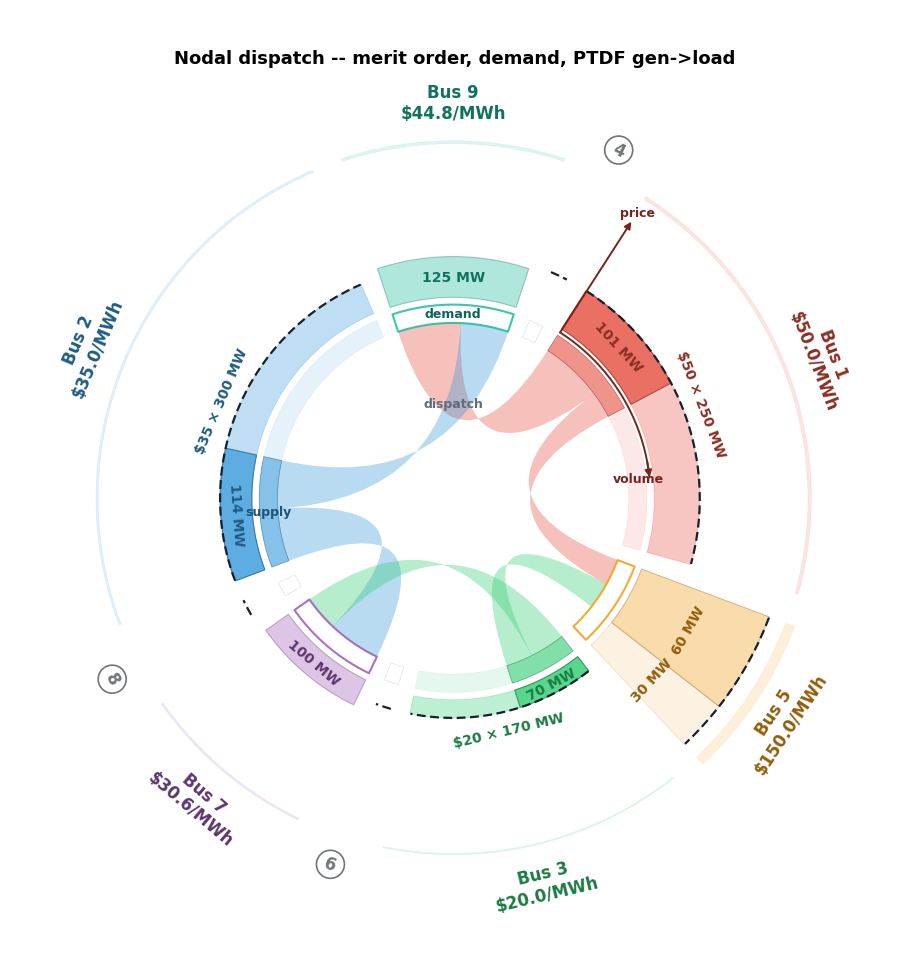

Binding transmission constraints -- congestion shadow price |mu_m|:

  line_2 (5-6): |mu| = $140.37/MWh   (flow -30 MW at the 30 MW limit)

  line_1 (4-5): |mu| = $94.39/MWh   (flow +30 MW at the 30 MW limit)

  line_4 (6-7): |mu| = $4.46/MWh   (flow +40 MW at the 40 MW limit)


Settlement by node  (payments to generation vs payments by load):

...

Revenue adequacy is preserved by reducing the load SERVED, not by relaxing a line or serving unpaid load: shed load pays nothing, so paid-by-load - paid-to-gen still equals the line congestion rent exactly. The shed penalty (SHED_PRICE x MW) is an objective-function term -- the value of lost load -- not a settlement cash flow.


Marginal value of line capacity  (shadow price x flow, per line):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,101.1,250.0,False,0.0,0.0
line_1,4,5,30.0,30.0,True,94.39,2831.7
line_2,5,6,-30.0,30.0,True,140.37,4211.0
line_3,3,6,70.0,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,4.46,178.5
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-113.9,250.0,False,0.0,0.0
line_7,8,9,53.9,250.0,False,0.0,0.0
line_8,9,4,-71.1,250.0,False,0.0,0.0


The |mu| column is the value of relaxing each line by 1 MW; only binding lines carry a positive value.
The rent column decomposes the congestion rent above by line and totals $7,221.2/h.


wrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  C:\Users\docke\Projects\ASSUME\assume\testbed

In [8]:
# Nodal dispatch diagram (circlize / chord) of the unified clearing (reuses sup, dem, colors, res from above).
flow_list = nodal_plot.compute_ptdf_flows(net, sup, served_demand(res, dem))   # PTDF-traced gen->load chords (on SERVED load)

fig = plot_nodal_circlize(
    sup, dem, pt.buses,
    flows=flow_list,
    clearing_price=res.energy_price,
    bus_lmps=res.lmp,
    bus_colors=colors,
    demand_segments=shed_segments(res, dem),   # faint tail (bus colour) = shed (unserved) load
    lmp_line=True,   # dashed line = bus LMP; solid bar height = unit marginal cost (gap = inframarginal rent)
    annotate_roles=True,   # one-time supply/demand/transfers key near 12 o'clock
    axis_key=True,         # illustrative price (up) / volume (across) L-axis in the corner
    sector_order=RING_ORDER,   # clockwise from 12 o'clock, following the network ring
    center_bus=CENTER_BUS,     # bus 9 centred at 12 o'clock (matches the rotated node diagram)
    figsize=(8.5, 9.0),        # fills the width of an 8.5x11 page (extra height -> title headroom)
    label_fontsize=12,         # outer sector labels (Bus N / LMP)
    track_fontsize=10,         # in-track bid / dispatch / load-MW labels, >= 10 pt
    show_legend=False,         # per-bus gen/load/LMP already on the ring + in-track; legend was sub-10 pt and duplicative
    title='Nodal dispatch -- merit order, demand, PTDF gen->load',
)
plt.show()

# Shadow price of the binding line constraint(s): the congestion dual mu_m.
binding = {l: mu for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
if binding:
    print('Binding transmission constraints -- congestion shadow price |mu_m|:')
    for l, mu in sorted(binding.items(), key=lambda kv: -abs(kv[1])):
        i = pt.line_idx[l]; a, b = pt.line_buses[i]
        print(f'  {l} ({a}-{b}): |mu| = ${abs(mu):.2f}/MWh   '
              f'(flow {res.flow_own[l]:+.0f} MW at the {pt.s_nom[i]:.0f} MW limit)')
else:
    print('No binding line constraints -- every bus collapses to the single energy price.')

# ── Settlement accounting: payments by node, subtotals, congestion rent ──────
# Convention: "paid to gen" is cash IN to generators (LMP x dispatch); "paid by
# load" is cash OUT from loads (LMP x demand). The system operator collects the
# difference as congestion rent / merchandising surplus -- and that residual
# equals the shadow-price money  sum_m |mu_m| * F_m  (the price-difference rent).
settle = pd.DataFrame(
    [{'bus': b,
      'LMP ($/MWh)': round(res.lmp[b], 2),
      'gen (MW)': round(res.gen_by_bus.get(b, 0.0), 1),
      'paid to gen ($/h)': round(res.lmp[b] * res.gen_by_bus.get(b, 0.0), 1),
      'load (MW)': round(unified.loads.get(b, 0.0), 1),
      'served (MW)': round(unified.loads.get(b, 0.0) - res.shed_by_bus.get(b, 0.0), 1),
      'paid by load ($/h)': round(res.lmp[b] * (unified.loads.get(b, 0.0)
                                                - res.shed_by_bus.get(b, 0.0)), 1)}
     for b in pt.buses]
).set_index('bus')

# Settle on SERVED load: shed (unserved) load consumes nothing and pays nothing.
gen_rev  = settle['paid to gen ($/h)'].sum()    # subtotal: total to generation
load_pay = settle['paid by load ($/h)'].sum()   # subtotal: total from served load
settle.loc['SUBTOTAL'] = ['', settle['gen (MW)'].sum(), gen_rev,
                          settle['load (MW)'].sum(), settle['served (MW)'].sum(), load_pay]

print('\nSettlement by node  (payments to generation vs payments by load):')
display(settle)

cong_rent = load_pay - gen_rev
mu_money  = sum(abs(mu) * abs(res.flow_own[l]) for l, mu in binding.items())
print(f'Congestion rent  =  paid by load  -  paid to gen  '
      f'=  {load_pay:,.1f}  -  {gen_rev:,.1f}  =  ${cong_rent:,.1f}/h')
print(f'Shadow-price check:  sum_m |mu_m| * F_m over binding lines  =  ${mu_money:,.1f}/h')
print('(equal by the LMP decomposition: the energy component nets to zero because '
      'total generation = total SERVED load,\n so only the congestion term survives, and it equals mu x flow on each binding line.)')

# Load shedding (power-balance relaxation): if any load is unserved, settlement
# is on SERVED load, so the rent identity above still balances -- revenue
# adequacy holds with NO relaxed line limits and NO unpaid phantom load.
_shed_total = sum(res.shed_by_bus.values())
if _shed_total > 1e-6:
    _where = ', '.join(f'bus {b} {u:.0f} MW' for b, u in res.shed_by_bus.items())
    print(f'\nLoad shed: {_shed_total:.0f} MW unserved ({_where}), each shed bus priced at '
          f'SHED_PRICE = ${SHED_PRICE:.0f}/MWh (its LMP -- the relaxation penalty is the price cap).')
    print('Revenue adequacy is preserved by reducing the load SERVED, not by relaxing a line or '
          'serving unpaid load: shed load pays nothing, so paid-by-load - paid-to-gen still equals '
          'the line congestion rent exactly. The shed penalty (SHED_PRICE x MW) is an '
          'objective-function term -- the value of lost load -- not a settlement cash flow.')

# ── Marginal value of line capacity: shadow price x flow, per line ───────────
# |mu_m| is the $/MWh fall in system cost from +1 MW of rating on line m (zero
# unless the line binds) -- the marginal value of capacity. |mu_m| x flow is the
# congestion rent that line collects; the column sums to the total rent above.
lines_tbl = pd.DataFrame(
    [{'line': l,
      'from': pt.line_buses[pt.line_idx[l]][0],
      'to': pt.line_buses[pt.line_idx[l]][1],
      'flow (MW)': round(res.flow_own[l], 1),
      'rating (MW)': round(pt.s_nom[pt.line_idx[l]], 0),
      'binding': abs(res.line_dual[l]) > 1e-3,
      '|mu| ($/MWh = value of +1 MW)': round(abs(res.line_dual[l]), 2),
      'rent |mu| x flow ($/h)': round(abs(res.line_dual[l]) * abs(res.flow_own[l]), 1)}
     for l in pt.lines]
).set_index('line')
lines_tbl.loc['TOTAL'] = ['', '', '', '', '', '',
                          round(lines_tbl['rent |mu| x flow ($/h)'].sum(), 1)]

print('\nMarginal value of line capacity  (shadow price x flow, per line):')
display(lines_tbl)
print('The |mu| column is the value of relaxing each line by 1 MW; only binding '
      'lines carry a positive value.\nThe rent column decomposes the congestion '
      f'rent above by line and totals ${lines_tbl.loc["TOTAL", "rent |mu| x flow ($/h)"]:,.1f}/h.')

# ── Export both tables to CSV (overwritten every run) for the Word write-up ──
settle.to_csv('seams_settlement_by_node.csv')
lines_tbl.to_csv('seams_line_capacity_value.csv')
print(f'\nwrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  {os.getcwd()}')

### Composite figure 

The network diagram and the nodal dispatch diagram laid out side by side,
sized so the fonts stay clean at half-page width:

- node numbers sit in small chips **beside** each bubble (the coloured marker stays
  uncluttered); only the **LMP** is printed at each bus — the gen/bid/load detail
  lives in the nodal dispatch panel, so nothing is duplicated;
- on each bus sector the **bid** sits *outside / on top of* the gen bar and the
  **dispatched MW** sits *inside* it (mirroring the load bar, which prints its MW
  in-track); in-track labels are placed by bar height so they stay inside the bar;
- saved as a PNG and a vector PDF, overwritten each run.

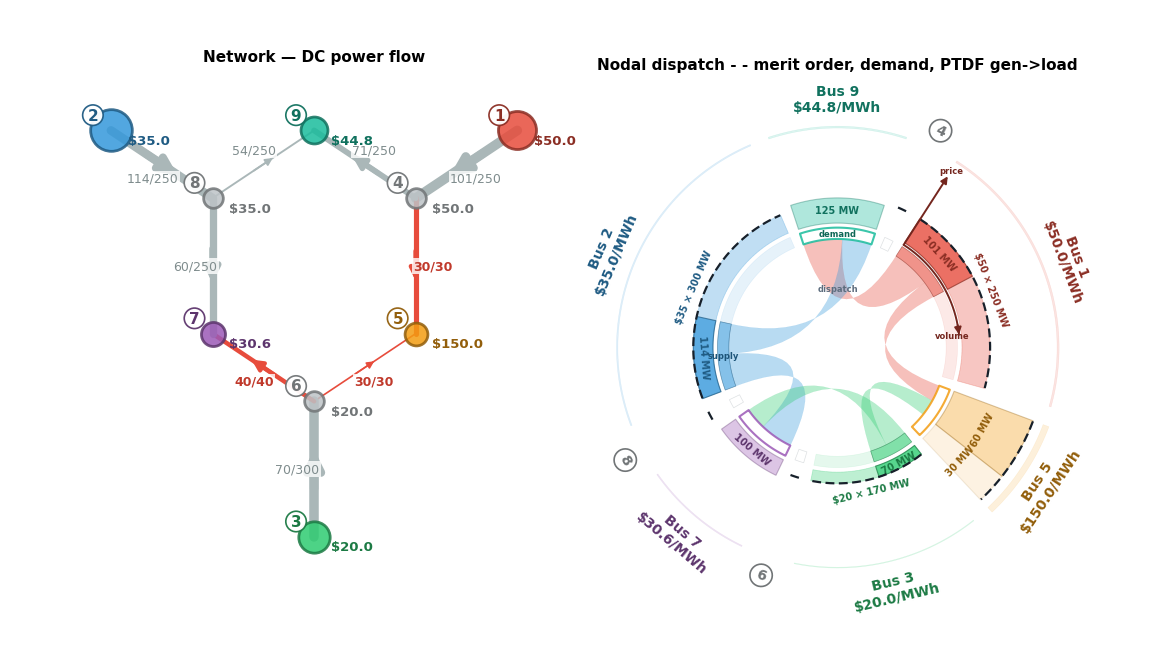

wrote cra_combined_figure.png (600 dpi) and cra_combined_figure.pdf to C:\Users\docke\Projects\ASSUME\assume\testbed

In [9]:
from nodal_plot import plot_combined_letter

binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, (ax_net, ax_circ) = plot_combined_letter(
    net, sup, dem,
    bus_colors=colors, bus_lmps=res.lmp,
    line_flows={l: res.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines,
    flows=nodal_plot.compute_ptdf_flows(net, sup, served_demand(res, dem)),
    clearing_price=res.energy_price,
    demand_segments=shed_segments(res, dem),   # faint tail (bus colour) = shed (unserved) load
    lmp_line=True,   # dashed line = bus LMP; solid bar height = unit marginal cost
    annotate_roles=True,   # one-time supply/demand/transfers key near 12 o'clock
    axis_key=True,         # illustrative price (up) / volume (across) L-axis in the corner
    all_buses=pt.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,   # rotated node diagram + bus 9 at 12 o'clock
    title_right='Nodal dispatch - - merit order, demand, PTDF gen->load',
)
fig.savefig('cra_combined_figure.png', dpi=600, bbox_inches='tight')
fig.savefig('cra_combined_figure.pdf', bbox_inches='tight')   # vector, for Word
plt.show()
print(f'wrote cra_combined_figure.png (600 dpi) and cra_combined_figure.pdf to {os.getcwd()}')

**Read it:** with `line_4` (6–7) limited to 40 MW, the binding internal limit
splits the LMPs — the bus-7 load behind the constraint prices up to ~\$37 while the
cheap bus-3 pocket (\$20) stays low. The congestion term is exactly
$\sum_m SF_{n,m}\,\mu_m$; set `LINE_RATINGS = {}` and re-run to collapse every bus
back to a single energy price.

## 3. Transport constraints and transfer rent

Nodal pricing constrains individual *lines*. Markets also limit **transport
between areas**: group the buses into two regions and hold the **net interchange**
\(E\) (region A's net export, equal to the summed flow across the interface) within
a scheduling limit \(\bar E\):

$$-\bar E \;\le\; E \;\le\; \bar E \qquad [\,\mu_T\,].$$

When the limit binds it carries a shadow price \(\mu_T\); every bus in region A
picks up the same \(+\mu_T\) term, so the two regions' energy prices separate by
\(\mu_T\). The **transfer rent** is

$$R_T \;=\; |\,\mu_T \cdot E\,| ,$$

the transport analogue of line congestion rent. (`revenue_allocation.solve_with_transfer`
adds the constraint; `transfer_rent` reads \(R_T\) off the dual.)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Region A net export: unconstrained +215 MW  ->  capped at 150 MW

transfer shadow price |mu_T| = $15.00/MWh   (prices separate by this between the regions)

transfer rent  R_T = |mu_T * E| = $2,250.0/h

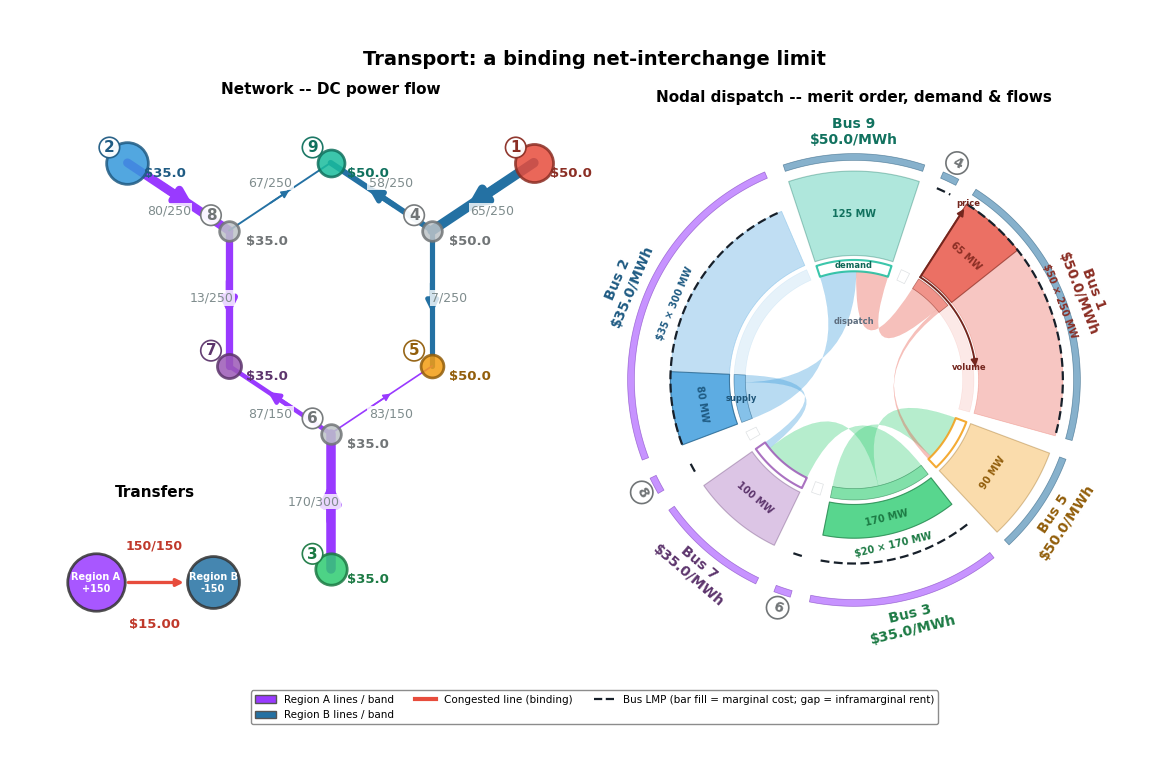

In [10]:
# Two regions on the same network; cap the net interchange between them.
REGIONS = {'Region A': ['2', '8', '7', '6', '3'], 'Region B': ['1', '9', '4', '5']}
REGION_COLORS = {'Region A': '#993AFF', 'Region B': '#2471A3'}
REGION_LINES  = {'Region A': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],
                 'Region B': ['line_0', 'line_1', 'line_7', 'line_8']}
ptU = shift_factors()
fp  = fpmod.make(ptU, REGIONS, REGION_COLORS, manage=REGION_LINES, tie_label='tie')
TIE_CAP = float(sum(ptU.s_nom[ptU.line_idx[l]] for l in fp.ties))   # combined interface rating

# Clear once with a slack limit to read the natural interchange, then cap below it.
_, _, _, r0 = ra.solve_with_transfer(fp, {}, TIE_CAP)
E0 = r0.interchange_mw
TRANSFER_LIMIT = round(abs(E0) * 0.7 / 5) * 5                       # tighten so the schedule binds
n_t, p_t, e_t, r_t = ra.solve_with_transfer(fp, {}, TRANSFER_LIMIT)
print(f'Region A net export: unconstrained {E0:+.0f} MW  ->  capped at {TRANSFER_LIMIT:.0f} MW')
print(f'transfer shadow price |mu_T| = ${abs(r_t.interchange_dual):.2f}/MWh   '
      f'(prices separate by this between the regions)')
print(f'transfer rent  R_T = |mu_T * E| = ${ra.transfer_rent(r_t):,.1f}/h')
figs.transfer_figure(n_t, p_t, fp, e_t, r_t, TRANSFER_LIMIT, TIE_CAP,
                     suptitle='Transport: a binding net-interchange limit')
plt.show()

## 4. Self-schedules

A **self-schedule** is a fixed, price-taking injection \(\mathrm{exo}_n\) the clear
must absorb — a quantity, with no bid price. It shifts a region's residual supply
curve and moves the LMPs without *setting* one. Below, an 80 MW self-schedule
delivered into bus 9 (a load bus in the expensive region) displaces local supply
and pulls its LMP toward the cheaper region's price. (`solve_engine_dispatch(exo=…)`
carries it; `+` = injection into the footprint.)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


self-schedule: 80 MW delivered into bus 9

,1,2,3,4,5,6,7,8,9
LMP base ($/MWh),35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0
LMP w/ self-sched ($/MWh),35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0


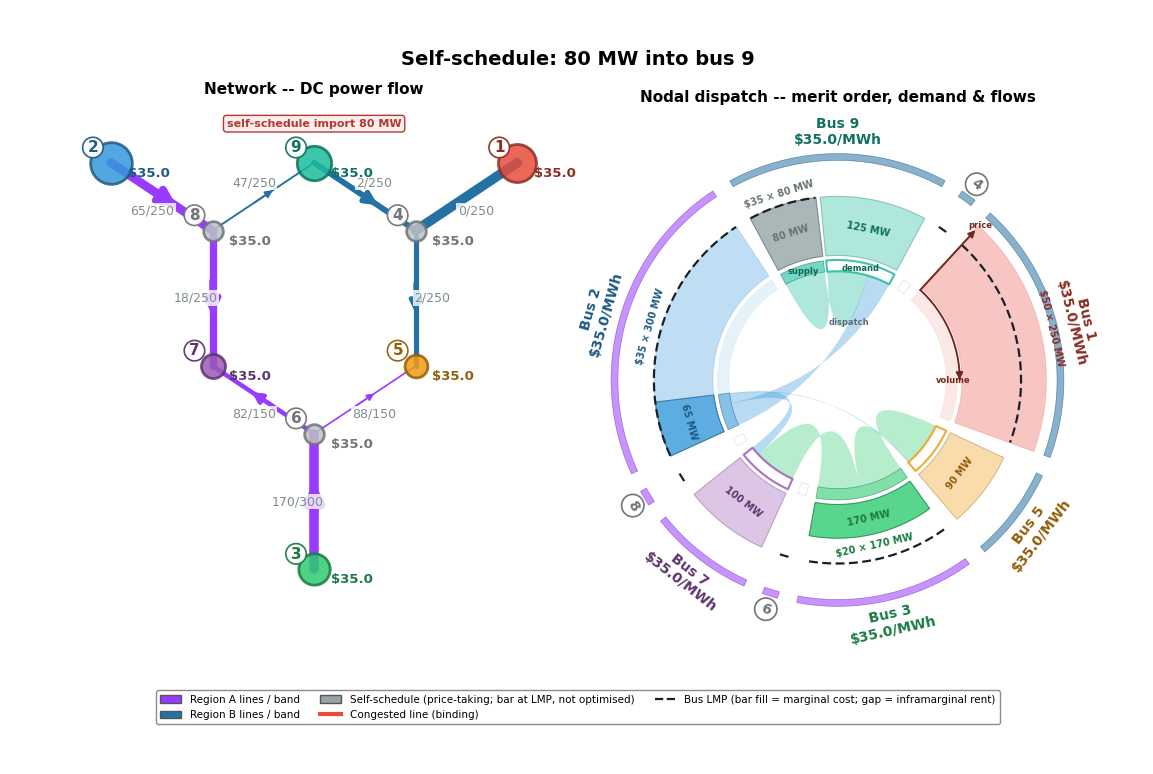

In [11]:
SELF_BUS, SELF_MW = '9', 80.0
n_s = build_network(); p_s = compute_ptdf(n_s, slack_bus='1')
eng_s = make_engine('UNIFIED', buses=p_s.buses)
r_base = solve_engine_dispatch(p_s, eng_s)
r_self = solve_engine_dispatch(p_s, eng_s, exo={SELF_BUS: SELF_MW})

cmp = pd.DataFrame({
    'LMP base ($/MWh)':       {b: round(r_base.lmp[b], 2) for b in p_s.buses},
    'LMP w/ self-sched ($/MWh)': {b: round(r_self.lmp[b], 2) for b in p_s.buses},
}).T
print(f'self-schedule: {SELF_MW:.0f} MW delivered into bus {SELF_BUS}')
display(cmp)
figs.footprint_figure(n_s, p_s, fp, eng_s, r_self, exo_sched={SELF_BUS: SELF_MW},
                      suptitle=f'Self-schedule: {SELF_MW:.0f} MW into bus {SELF_BUS}')
plt.show()

## 5. Three settlement ledgers

Every later notebook settles with one of three ledgers. All three close exactly —
positions sum to \(-(\text{production cost})\), and any pure transfer price nets out
at the system total.

1. **Congestion-revenue ledger** — each region's consumers and generators at nodal
   LMPs. The line congestion rent \(R\) is the gap between what load pays and what
   generation is paid; it is money the **system** holds, and it appears in the TOTAL
   column. Each region collects the part its *own* prices create — its load payment
   minus its generator revenue. **How that pooled rent is then allocated back between
   the balancing authorities is a policy choice**, not a fact of the dispatch; this
   fundamentals notebook does not pick a rule (the 201 notebook is devoted to it).
2. **Transfer-revenue ledger** — the same layout for the transport-constrained clear:
   the transfer rent \(R_T=|\mu_T\,E|\), collected at the interface, joins the TOTAL.
3. **Position ledger** — per-region net positions (consumers, generator surplus, a
   trader/self-schedule row) — the form the seams and two-settlement notebooks use.

In [12]:
# (1) Congestion-revenue ledger — a line-constrained clear. The congestion rent R
# is collected by the system; each region collects the part its own prices create
# (load payment - generator revenue). It is NOT allocated between the regions here
# (that is a policy choice -- see the 201 notebook); it simply lands in the TOTAL.
rat_c = {'line_4': 40.0}
n_c = build_network(rat_c); p_c = compute_ptdf(n_c, slack_bus='1')
r_c = solve_engine_dispatch(p_c, make_engine('UNIFIED', buses=p_c.buses), shed_price=150.0)

s_c = ra.ba_settlement(fp, r_c, LOADS)
cong = pd.DataFrame({reg: {
    'Load payment  (lmp x d)':                          s_c[reg]['load_pay'],
    'Generator revenue  (lmp x g)':                     s_c[reg]['gen_rev'],
    'Congestion rent collected  (load pay - gen rev)':  s_c[reg]['net_into_pool'],
} for reg in fp.areas})
cong['TOTAL'] = cong.sum(axis=1)
R_c = cong.loc['Congestion rent collected  (load pay - gen rev)', 'TOTAL']
print(f'congestion rent  R = ${R_c:,.1f}/h  -- held by the system (the TOTAL column); '
      f'allocating it between the BAs is a policy choice.')
display(cong.round(1))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


congestion rent  R = $804.1/h  -- held by the system (the TOTAL column); allocating it between the BAs is a policy choice.

,Region A,Region B,TOTAL
Load payment (lmp x d),3712.6,6032.5,9745.1
Generator revenue (lmp x g),8941.0,0.0,8941.0
Congestion rent collected (load pay - gen rev),-5228.4,6032.5,804.1


### Do both regions gain vs going it alone? (autarky Pareto test)

A natural fairness check: is each region at least as well off under the unified
clearing as under **autarky** (serving its own load on its own lines)? The check
needs the pooled congestion rent rebated *somehow*, and that is exactly the policy
choice above. Here we use the simplest neutral default — **rebate the rent to load
pro-rata by load share**, a uniform consumer uplift. Treat this as one *general
uplift methodology*; the 201 notebook explores allocation rules (and their
distributional consequences) in depth.

In [13]:
# Pro-rata-by-load uplift of the total congestion rent (a general uplift rule).
_, indep_c = ra.independent_clear(fp, rat_c, shed_price=150.0)
_R = sum(ra.ba_settlement(fp, r_c, LOADS)[reg]['net_into_pool'] for reg in fp.names)
_load = {reg: sum(LOADS.get(b, 0.0) for b in fp.defs[reg]) for reg in fp.names}
prorata = pd.DataFrame({'method1': {reg: _R * _load[reg] / sum(_load.values()) for reg in fp.names}})
print('congestion rent rebated to load pro-rata by load share:',
      {reg: round(prorata.loc[reg, 'method1'], 1) for reg in fp.names})
display(ra.autarky_vs_unified(fp, 1, prorata, indep_c, r_c, LOADS))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


congestion rent rebated to load pro-rata by load share:

{'Region A': np.float64(255.3), 'Region B': np.float64(548.8)}

Region A           Region B          
                                   Consumer Generator Consumer Generator
Autarky: payment / revenue          -3712.6    2908.5 -10750.0   10750.0
Autarky: production cost                      -2908.5           -10750.0
Autarky: own congestion rent (CRR)    804.1                0.0          
Autarky: position                   -2908.5       0.0 -10750.0       0.0
Unified: payment / revenue          -3712.6    8941.0  -6032.5       0.0
Unified: production cost                      -8941.0               -0.0
Congestion rent (CRR)                 255.3              548.8          
Final position                      -3457.3       0.0  -5483.7       0.0
Delta vs autarky                     -548.8       0.0   5266.3       0.0
Pareto (Delta >= 0)                      no       yes      yes       yes

In [14]:
# (2) Transfer-revenue ledger — the transport-constrained clear from §3. The
# transfer rent R_T = |mu_T * E| is collected at the interface (it belongs to the
# schedule, not to either region's wires). Like the congestion rent it is not
# allocated here; the total rent each region's prices create lands in the TOTAL.
s_t = ra.ba_settlement(fp, r_t, LOADS)
xfer = pd.DataFrame({reg: {
    'Load payment  (lmp x d)':                 s_t[reg]['load_pay'],
    'Generator revenue  (lmp x g)':            s_t[reg]['gen_rev'],
    'Rent collected  (load pay - gen rev)':    s_t[reg]['net_into_pool'],
} for reg in fp.areas})
xfer['TOTAL'] = xfer.sum(axis=1)
R_t_cong = ra.allocate_congestion_rent(fp, r_t, p_t, LOADS)[1]['R']
R_t_xfer = ra.transfer_rent(r_t)
print(f'total rent collected = ${R_t_cong + R_t_xfer:,.1f}/h  =  congestion R ${R_t_cong:,.1f}'
      f'  +  transfer R_T ${R_t_xfer:,.1f}  (|mu_T * E|, collected at the interface)')
display(xfer.round(1))

total rent collected = $2,250.0/h  =  congestion R $0.0  +  transfer R_T $2,250.0  (|mu_T * E|, collected at the interface)

,Region A,Region B,TOTAL
Load payment (lmp x d),3500.0,10750.0,14250.0
Generator revenue (lmp x g),8750.0,3250.0,12000.0
Rent collected (load pay - gen rev),-5250.0,7500.0,2250.0


In [15]:
# (3) Position ledger — per-region net positions at the unconstrained clear,
# with a worked self-schedule leg (a pure transfer that cancels at the system total).
n_u = build_network(); p_u = compute_ptdf(n_u, slack_bus='1')
r_u = solve_engine_dispatch(p_u, make_engine('UNIFIED', buses=p_u.buses))
pl = ra.position_ledger(fp, r_u, trader=0.0, trader_label='Self-schedule')
led = pd.DataFrame(pd.Series(pl), columns=['$/h']).round(1)
led.index = pd.MultiIndex.from_tuples(led.index)
display(led)
parties = sum(v for k, v in pl.items() if k[0] != 'Total')
print(f'consumers + generators + self-schedule = ${parties:,.1f}/h  '
      f'(= -(congestion rent + production cost); pure transfers net out)')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


$/h
Region A      consumers       -3500.0
              generators       2550.0
Region B      consumers       -7525.0
              generators          0.0
Self-schedule                     0.0
Total         production cost -8475.0

consumers + generators + self-schedule = $-8,475.0/h  (= -(congestion rent + production cost); pure transfers net out)

## 6. Sandbox

Dial a scenario and watch the revenue flows respond. Toggle line ratings
(congestion), an optional net-interchange cap on region A (transport), and a
self-schedule. Re-run to see the dispatch, the congestion rent \(R\), the transfer
rent \(R_T\), and the rent each region collects move together. No issue is framed — this is
the generic playground the 200- and 300-series notebooks specialise.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


congestion rent  R = $804.1/h    transfer rent  R_T = $0.0/h    load shed: 0 MW

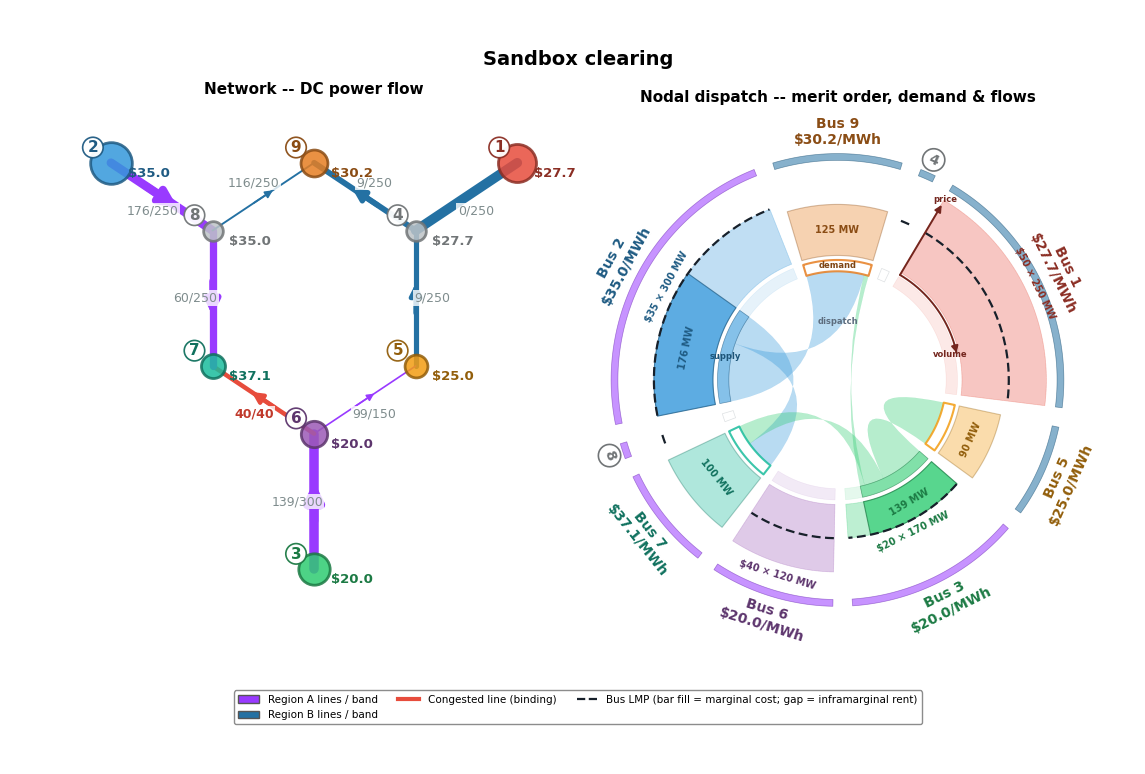

,Region A,Region B,TOTAL
Load payment,3712.6,6032.5,9745.1
Generator revenue,8941.0,0.0,8941.0
Congestion rent collected (net),-5228.4,6032.5,804.1


In [16]:
# -- EDIT -- a full free-form scenario. Every main input is configurable, and a
# bus may gain or lose a generator/load it did not start with.
# Generators -- {bus: (marginal cost $/MWh, capacity MW)}. Add a unit at a
# load-only bus (uncomment bus 5), drop one, or re-cost / re-size any.
SB_GENS = {
    "1": (50.0, 250.0),    # slack, most expensive
    "2": (35.0, 300.0),    # mid-merit
    "3": (20.0, 170.0),    # cheapest
    "6": (40.0, 120.0),  # <- e.g. put a generator where there was only load
}
SB_LOADS = {"5": 90.0, "7": 100.0, "9": 125.0}   # {bus: MW}; add/resize load at any bus
SB_RATINGS  = {"line_4": 40.0}   # line limits (congestion); {} = none
SB_TRANSFER = None               # MW cap on Region A net interchange (None = off)
SB_SELF     = {}                 # {bus: MW} self-schedule (price-taking); {} = none
SHED_PRICE  = 150.0              # load-shed penalty ($/MWh)
# ---------------------------------------------------------------------------
SB_FLEET = {f"gen_{b}": {"bus": b, "cost": c, "p_nom": p} for b, (c, p) in SB_GENS.items()}
n_sb = build_network(SB_RATINGS); p_sb = compute_ptdf(n_sb, slack_bus="1")
eng_sb = make_engine("UNIFIED", buses=p_sb.buses, gen_fleet=SB_FLEET, loads=SB_LOADS)
kw = dict(exo=(SB_SELF or None), shed_price=SHED_PRICE)
if SB_TRANSFER is not None:
    kw["interchange"] = (fp.defs[fp.names[0]], SB_TRANSFER)
r_sb = solve_engine_dispatch(p_sb, eng_sb, **kw)

R  = ra.allocate_congestion_rent(fp, r_sb, p_sb, SB_LOADS)[1]["R"]
RT = ra.transfer_rent(r_sb)
print(f"congestion rent  R = ${R:,.1f}/h    transfer rent  R_T = ${RT:,.1f}/h    "
      f"load shed: {sum(r_sb.shed_by_bus.values()):.0f} MW")

# Colours follow the sandbox fleet so a newly-active bus gets its own colour.
_sbsup = {}
for _g, _s in SB_FLEET.items():
    _sbsup.setdefault(_s["bus"], []).append(_s)
sb_colors = assign_bus_colors(p_sb.buses, _sbsup, SB_LOADS)

figs.footprint_figure(n_sb, p_sb, fp, eng_sb, r_sb, exo_sched=(SB_SELF or None),
                      bus_colors=sb_colors, suptitle="Sandbox clearing")
plt.show()
s_sb = ra.ba_settlement(fp, r_sb, SB_LOADS)
sb_tbl = pd.DataFrame({reg: {
    'Load payment':                        s_sb[reg]['load_pay'],
    'Generator revenue':                   s_sb[reg]['gen_rev'],
    'Congestion rent collected (net)':     s_sb[reg]['net_into_pool'],
} for reg in fp.areas})
sb_tbl['TOTAL'] = sb_tbl.sum(axis=1)
display(sb_tbl.round(1))